In [1]:
import pandas as pd

# Load your dataset 
data = pd.read_csv("../InventoryDataset-Final-Cleaned.csv")
data.head()



,Order,File_Type,SKU_number,SoldFlag,SoldCount,MarketingType,ReleaseNumber,New_Release_Flag,StrengthFactor,PriceReg,ReleaseYear,ItemCount,LowUserPrice,LowNetPrice
0,2,historical,1737127,0.0,0.0,d,15,1,682743.0,44.99,2015,8,28.970000,31.84
1,3,historical,3255963,0.0,0.0,d,7,1,1016014.0,24.81,2005,39,30.982487,15.54
2,4,historical,612701,0.0,0.0,d,0,0,340464.0,46.00,2013,34,30.190000,27.97
3,6,historical,115883,1.0,1.0,d,4,1,334011.0,100.00,2006,20,133.930000,83.15
4,7,historical,863939,1.0,1.0,d,2,1,1287938.0,121.95,2010,28,4.000000,23.99


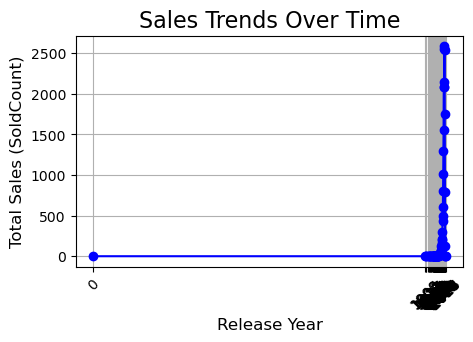

In [3]:
#Exploratory Data Analysis (EDA)
#A. Sales Trends Over Time

import matplotlib.pyplot as plt

# Aggregate sales by year
sales_trends = data.groupby('ReleaseYear')['SoldCount'].sum().reset_index()

# Plot sales trends
plt.figure(figsize=(5, 3))
plt.plot(sales_trends['ReleaseYear'], sales_trends['SoldCount'], marker='o', color='b')
plt.title('Sales Trends Over Time', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Total Sales (SoldCount)', fontsize=12)
plt.grid(True)
plt.xticks(sales_trends['ReleaseYear'], rotation=45)
plt.show()


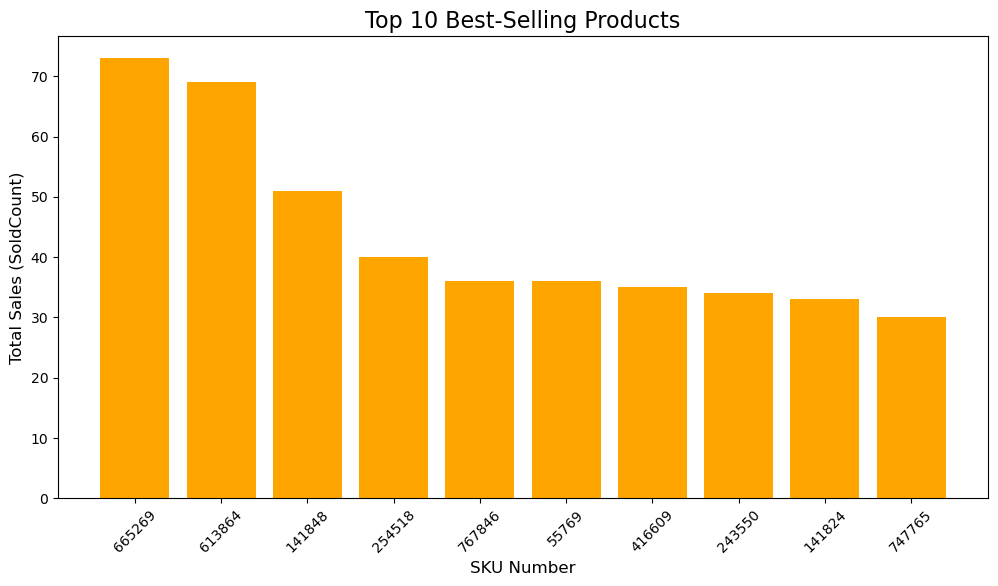

In [4]:
#B. Top-Selling Products
# Aggregate sales by SKU_number
top_products = data.groupby('SKU_number')['SoldCount'].sum().reset_index()
top_products = top_products.sort_values(by='SoldCount', ascending=False).head(10)

# Plot top-selling products
plt.figure(figsize=(12, 6))
plt.bar(top_products['SKU_number'].astype(str), top_products['SoldCount'], color='orange')
plt.title('Top 10 Best-Selling Products', fontsize=16)
plt.xlabel('SKU Number', fontsize=12)
plt.ylabel('Total Sales (SoldCount)', fontsize=12)
plt.xticks(rotation=45)
plt.show()


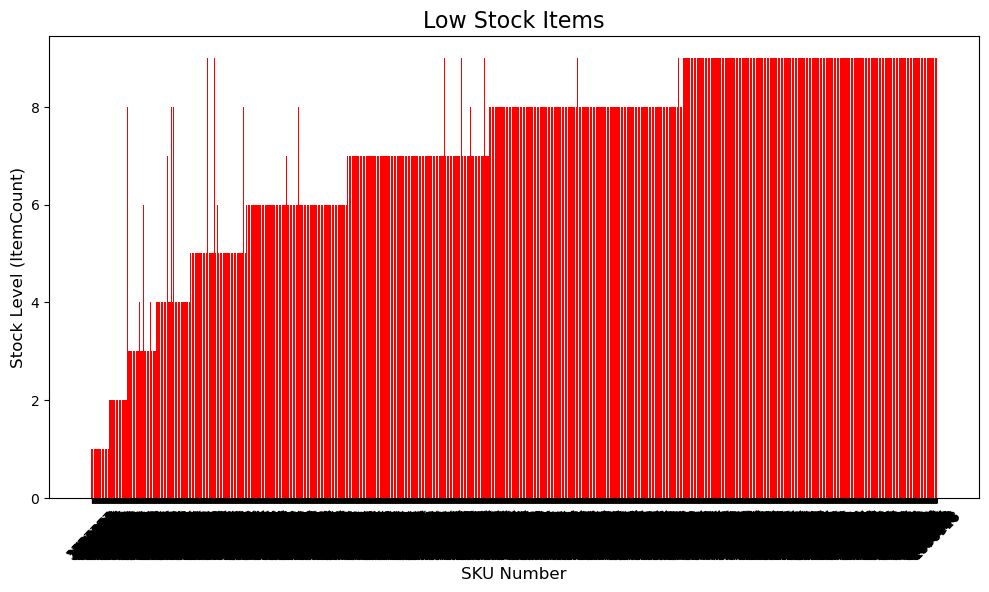

In [5]:
# Identify low-stock products (stock < 10 but not 0)
low_stock_items = data[(data['ItemCount'] < 10) & (data['ItemCount'] > 0)]  # Filter for products with stock between 0 and 10
low_stock_items_sorted = low_stock_items.sort_values(by='ItemCount')

# Plot low-stock items
plt.figure(figsize=(12, 6))
plt.bar(low_stock_items_sorted['SKU_number'].astype(str), low_stock_items_sorted['ItemCount'], color='red')
plt.title('Low Stock Items', fontsize=16)
plt.xlabel('SKU Number', fontsize=12)
plt.ylabel('Stock Level (ItemCount)', fontsize=12)
plt.xticks(rotation=45)
plt.show()




Correlation between ItemCount and SoldCount:
           ItemCount  SoldCount
ItemCount   1.000000   0.145395
SoldCount   0.145395   1.000000


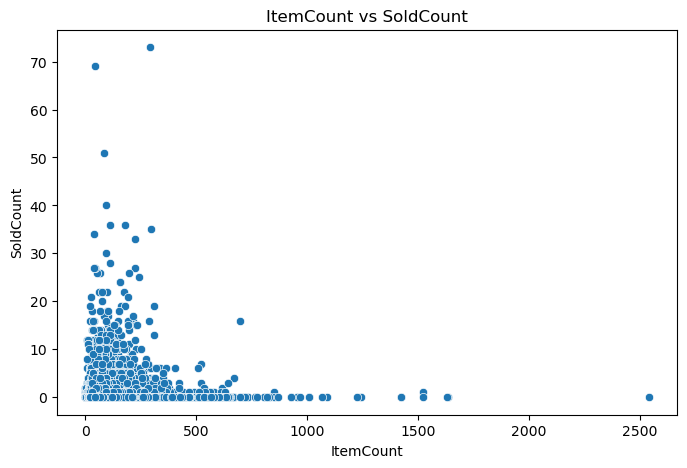

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# EDA: Correlation between ItemCount and SoldCount
correlation = data[['ItemCount', 'SoldCount']].corr()
print("\nCorrelation between ItemCount and SoldCount:")
print(correlation)

# Visualizations:
# Scatter plot to show relationship between ItemCount and SoldCount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='ItemCount', y='SoldCount')
plt.title('ItemCount vs SoldCount')
plt.xlabel('ItemCount')
plt.ylabel('SoldCount')
plt.show()





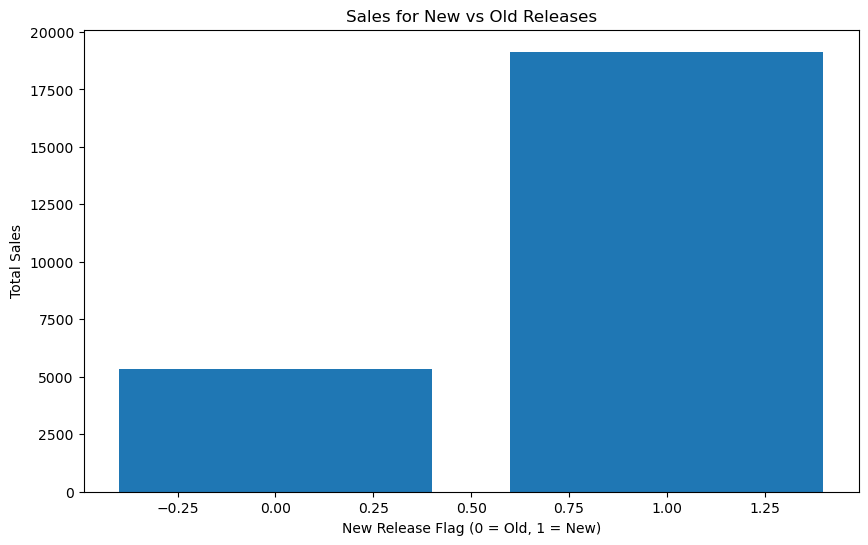

In [19]:
#New Release Products Analysis
# Sales for new and old releases
sales_by_release = data.groupby('New_Release_Flag')['SoldCount'].sum().reset_index()

# Plot sales for new vs old releases
plt.figure(figsize=(10, 6))
plt.bar(sales_by_release['New_Release_Flag'], sales_by_release['SoldCount'])
plt.title('Sales for New vs Old Releases')
plt.xlabel('New Release Flag (0 = Old, 1 = New)')
plt.ylabel('Total Sales')
plt.show()


In [8]:
#Inventory Turnover

# Calculate total sales and average inventory
total_sales = data['SoldCount'].sum()
average_inventory = data['ItemCount'].mean()

# Calculate inventory turnover ratio
inventory_turnover = total_sales / average_inventory
print(f"Inventory Turnover Ratio: {inventory_turnover:.2f}")


Inventory Turnover Ratio: 591.27


In [9]:
#Stock-to-Sales Ratio
# Calculate stock-to-sales ratio, avoid division by zero
data['Stock_to_Sales'] = data.apply(lambda row: row['ItemCount'] / row['SoldCount'] if row['SoldCount'] != 0 else 0, axis=1)

# Get average stock-to-sales ratio (ignore zeros)
avg_stock_to_sales = data[data['SoldCount'] > 0]['Stock_to_Sales'].mean()

print(f"Average Stock-to-Sales Ratio: {avg_stock_to_sales:.2f}")


Average Stock-to-Sales Ratio: 45.89


In [10]:
# Reorder Points
# Calculate average daily sales (assuming 30 days in a month)
average_daily_sales = data['SoldCount'].sum() / 30

# Define lead time (for example, 10 days)
lead_time = 10

# Calculate reorder point
reorder_point = average_daily_sales * lead_time
print(f"Reorder Point: {reorder_point:.2f} units")


Reorder Point: 8164.67 units


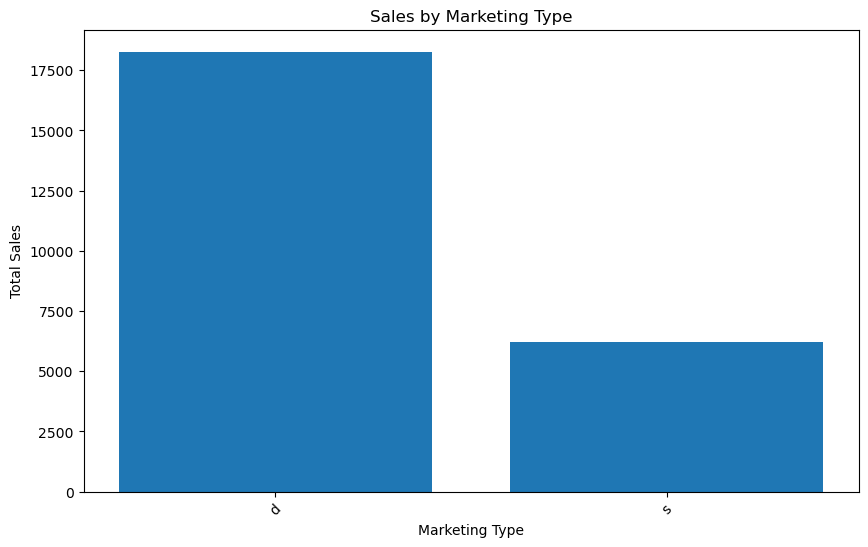

In [15]:
# Sales by Marketing Type
sales_by_marketing = data.groupby('MarketingType')['SoldCount'].sum().reset_index()

# Plot sales by marketing type
plt.figure(figsize=(10, 6))
plt.bar(sales_by_marketing['MarketingType'], sales_by_marketing['SoldCount'])
plt.title('Sales by Marketing Type')
plt.xlabel('Marketing Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

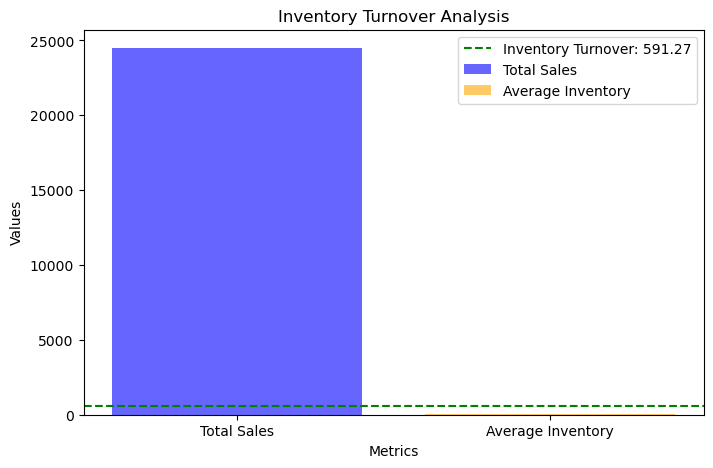

Inventory Turnover Ratio: 591.27


In [17]:

import matplotlib.pyplot as plt

# Assuming 'data' is a pandas DataFrame with 'SoldCount' and 'ItemCount' columns

# Calculate total sales and average inventory
total_sales = data['SoldCount'].sum()
average_inventory = data['ItemCount'].mean()

# Calculate inventory turnover ratio
inventory_turnover = total_sales / average_inventory

# Plot the data
plt.figure(figsize=(8, 5))

# Plot Total Sales and Average Inventory
plt.bar(['Total Sales'], [total_sales], color='blue', alpha=0.6, label='Total Sales')
plt.bar(['Average Inventory'], [average_inventory], color='orange', alpha=0.6, label='Average Inventory')

# Plot Inventory Turnover Ratio as a horizontal line
plt.axhline(inventory_turnover, color='green', linestyle='--', label=f'Inventory Turnover: {inventory_turnover:.2f}')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Inventory Turnover Analysis')

# Show legend
plt.legend()

# Show plot
plt.show()

# Print the calculated Inventory Turnover
print(f"Inventory Turnover Ratio: {inventory_turnover:.2f}")